# Sentiment Analysis Practice Notebook

Follow each instruction and write the code yourself in the empty cell below it. No solutions included — this is for practice.

In [16]:
import sys
!{sys.executable} -m pip install vaderSentiment

### 1. Setup
Import the libraries you'll need: `pandas`, `numpy`, `re`, `SentimentIntensityAnalyzer` from `vaderSentiment`, `pipeline` from `transformers`, and `train_test_split` / `metrics` from `sklearn`.

In [47]:
import pandas as pd
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score

### 2. Load data
Create a small DataFrame of book (or product) reviews with at least two columns: `reviewText` (string) and `rating` (integer 1-5). Include at least 8-10 rows with a mix of positive, negative, and neutral reviews.

Display the first few rows.

In [7]:
#always use () instead of {} while working data with pandas

reviews = [
 ("The world-building in this novel is breathtaking and kept me turning pages all night.", 5),
 ("The characters felt real and their growth made the story deeply satisfying.", 5),
 ("While the plot had promise, the pacing dragged in the middle chapters.", 3),
 ("I enjoyed the writing style, but the ending left too many loose threads.", 3),  
 ("This book is a charming read for anyone who loves thoughtful, quiet stories.", 4),  
 ("The dialogue was sharp and witty, although some scenes felt overly familiar.", 4),
 ("I appreciated the author's ambition, but the narrative never fully came together.", 2),  
 ("It was an interesting concept, and the execution was mostly competent.", 3),
 ("The prose is beautiful, but the main character's motivations were hard to believe.", 3),
 ("The story delivered what I expected—no surprises, but still a decent read.", 3),
 ("This book is a solid choice for fans of historical fiction with strong atmosphere.", 4),
 ("I didn't hate it, but it wasn't memorable enough to recommend to others.", 2),
]

data = pd.DataFrame(reviews,columns=['reviewText','rating'])
data.head()

,reviewText,rating
0,The world-building in this novel is breathtaki...,5
1,The characters felt real and their growth made...,5
2,"While the plot had promise, the pacing dragged...",3
3,"I enjoyed the writing style, but the ending le...",3
4,This book is a charming read for anyone who lo...,4


Check the structure of your DataFrame (data types, non-null counts, number of rows).

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  12 non-null     object
 1   rating      12 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


Print the raw text of the first review to confirm it looks right.

In [9]:
data['reviewText'][0]

'The world-building in this novel is breathtaking and kept me turning pages all night.'

### 3. Clean the data
Create a new column `reviewText_clean` that lowercases the review text.

In [11]:
data['reviewText_clean'] = data['reviewText'].str.lower()

Update `reviewText_clean` to remove punctuation (keep only word characters and whitespace).

In [13]:
data['reviewText_clean'] = data['reviewText_clean'].apply(lambda x: re.sub('[^\w\s]','',x))

Display the DataFrame to confirm the cleaned column looks correct.

In [14]:
data.head()

,reviewText,rating,reviewText_clean
0,The world-building in this novel is breathtaki...,5,the worldbuilding in this novel is breathtakin...
1,The characters felt real and their growth made...,5,the characters felt real and their growth made...
2,"While the plot had promise, the pacing dragged...",3,while the plot had promise the pacing dragged ...
3,"I enjoyed the writing style, but the ending le...",3,i enjoyed the writing style but the ending lef...
4,This book is a charming read for anyone who lo...,4,this book is a charming read for anyone who lo...


### 4. Rule-based sentiment with VADER
Initialize a `SentimentIntensityAnalyzer`.

In [22]:
vader_sentiment = SentimentIntensityAnalyzer()

Apply it to `reviewText_clean` to create a `vader_sentiment_score` column using the compound score.

In [25]:
data['vader_sentiment_score'] = data['reviewText_clean'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])
data.head()

,reviewText,rating,reviewText_clean,vader_sentiment_score
0,The world-building in this novel is breathtaki...,5,the worldbuilding in this novel is breathtakin...,0.6833
1,The characters felt real and their growth made...,5,the characters felt real and their growth made...,0.7089
2,"While the plot had promise, the pacing dragged...",3,while the plot had promise the pacing dragged ...,0.2732
3,"I enjoyed the writing style, but the ending le...",3,i enjoyed the writing style but the ending lef...,-0.2023
4,This book is a charming read for anyone who lo...,4,this book is a charming read for anyone who lo...,0.8779


Bucket the scores into `negative`, `neutral`, and `positive` labels (e.g. using `pd.cut` with bins `[-1, -0.1, 0.1, 1]`) and store them in a `vader_sentiment_label` column.

In [27]:
bins = [-1,-0.1,0.1,1]
labels = ['negative','neutral','positive']

data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'],bins= bins,labels= labels)
data.head()

,reviewText,rating,reviewText_clean,vader_sentiment_score,vader_sentiment_label
0,The world-building in this novel is breathtaki...,5,the worldbuilding in this novel is breathtakin...,0.6833,positive
1,The characters felt real and their growth made...,5,the characters felt real and their growth made...,0.7089,positive
2,"While the plot had promise, the pacing dragged...",3,while the plot had promise the pacing dragged ...,0.2732,positive
3,"I enjoyed the writing style, but the ending le...",3,i enjoyed the writing style but the ending lef...,-0.2023,negative
4,This book is a charming read for anyone who lo...,4,this book is a charming read for anyone who lo...,0.8779,positive


Plot a bar chart showing the counts of each VADER sentiment label.

<Axes: xlabel='vader_sentiment_label'>

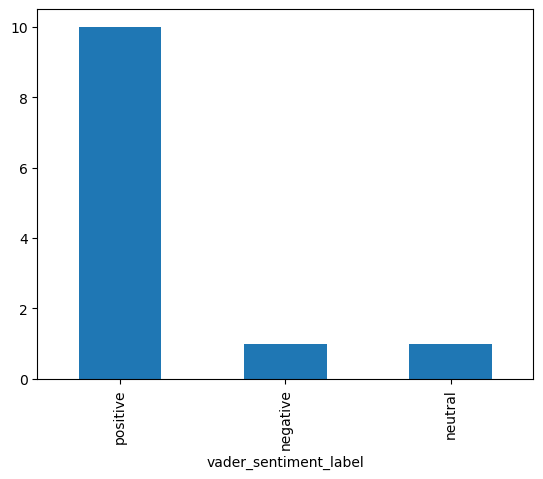

In [29]:
data['vader_sentiment_label'].value_counts().plot.bar()

### 5. Pre-trained transformer model
Load a `sentiment-analysis` pipeline from `transformers`.

In [30]:
import transformers
from transformers import pipeline

Run the pipeline over `reviewText_clean` for every row and store the predicted label(s) in a `transformer_sentiment_label` column.

In [35]:
sentiment_analysis = pipeline('sentiment-analysis')

data['transformer_sentiment_label'] = data['reviewText_clean'].apply(lambda x: sentiment_analysis(x)[0]['label'])
data.head()

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,reviewText,rating,reviewText_clean,vader_sentiment_score,vader_sentiment_label,transformer_sentiment_label
0,The world-building in this novel is breathtaki...,5,the worldbuilding in this novel is breathtakin...,0.6833,positive,POSITIVE
1,The characters felt real and their growth made...,5,the characters felt real and their growth made...,0.7089,positive,POSITIVE
2,"While the plot had promise, the pacing dragged...",3,while the plot had promise the pacing dragged ...,0.2732,positive,NEGATIVE
3,"I enjoyed the writing style, but the ending le...",3,i enjoyed the writing style but the ending lef...,-0.2023,negative,NEGATIVE
4,This book is a charming read for anyone who lo...,4,this book is a charming read for anyone who lo...,0.8779,positive,POSITIVE


Plot a bar chart showing the counts of each transformer sentiment label.

<Axes: ylabel='transformer_sentiment_label'>

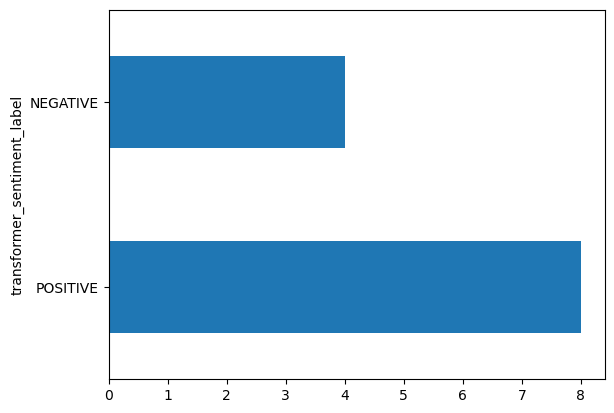

In [37]:
data['transformer_sentiment_label'].value_counts().plot.barh()

### 6. Compare against the star rating
Write a function that maps a star `rating` to a label: 1-2 → `negative`, 3 → `neutral`, 4-5 → `positive`. Apply it to create a `rating_label` column.

In [43]:
bin = [0,2,3,5]
labels = ['negative','neutral','positive']
data['rating_label'] = pd.cut(data['rating'],bins = bin , labels= labels)

data.head()

,reviewText,rating,reviewText_clean,vader_sentiment_score,vader_sentiment_label,transformer_sentiment_label,rating_label
0,The world-building in this novel is breathtaki...,5,the worldbuilding in this novel is breathtakin...,0.6833,positive,POSITIVE,positive
1,The characters felt real and their growth made...,5,the characters felt real and their growth made...,0.7089,positive,POSITIVE,positive
2,"While the plot had promise, the pacing dragged...",3,while the plot had promise the pacing dragged ...,0.2732,positive,NEGATIVE,neutral
3,"I enjoyed the writing style, but the ending le...",3,i enjoyed the writing style but the ending lef...,-0.2023,negative,NEGATIVE,neutral
4,This book is a charming read for anyone who lo...,4,this book is a charming read for anyone who lo...,0.8779,positive,POSITIVE,positive


Calculate the agreement (accuracy) between `rating_label` and `vader_sentiment_label`.

In [49]:
accuracy = accuracy_score(data['rating_label'] , data['vader_sentiment_label'].astype(str),)
print(f'Accuracy {accuracy:.2%}')


Accuracy 33.33%


## Further practice

1. Swap in a real dataset (CSV) instead of your hand-written sample.
2. Try different VADER thresholds and see how the label distribution changes.
3. Compute a confusion matrix and classification report comparing `vader_sentiment_label` (or the transformer labels) against `rating_label`.
4. Try a different transformer model by passing `model="..."` to `pipeline("sentiment-analysis", model=...)`.
5. Add stopword removal and lemmatization to the cleaning step and see if scores change.
6. Split the data with `train_test_split` and train your own classifier (e.g. Naive Bayes) using `rating_label` as the target.

In [51]:
data2 = pd.read_csv("116 - book-reviews-sample.csv")
data2.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [53]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   index       100 non-null    int64 
 1   reviewText  100 non-null    object
 2   rating      100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB
